In [35]:
import os
import numpy as np
import librosa

female_dir = "NewOneData/Female"
male_dir = "NewOneData/Male"

female_signals = []
male_signals = []  


for file in os.listdir(female_dir):
    if file.endswith(".wav"):
        file_path = os.path.join(female_dir, file)
        y, sr = librosa.load(file_path, sr=None)
        female_signals.append((y, sr, file))


for file in os.listdir(male_dir):
    if file.endswith(".wav"):
        file_path = os.path.join(male_dir, file)
        x, sr = librosa.load(file_path, sr=None)
        male_signals.append((x, sr, file))  

print(f"Total Female Samples Loaded: {len(female_signals)}")
print(f"Total Male Samples Loaded: {len(male_signals)}")


Total Female Samples Loaded: 50
Total Male Samples Loaded: 50


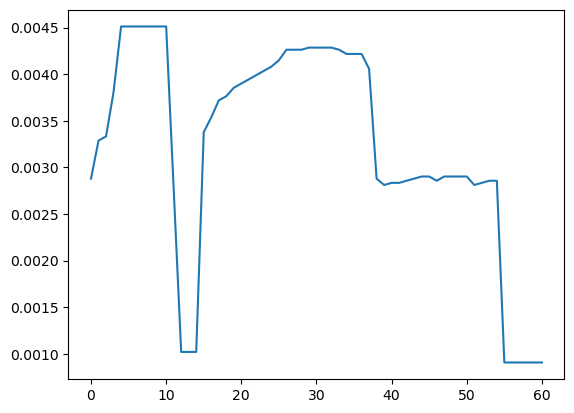

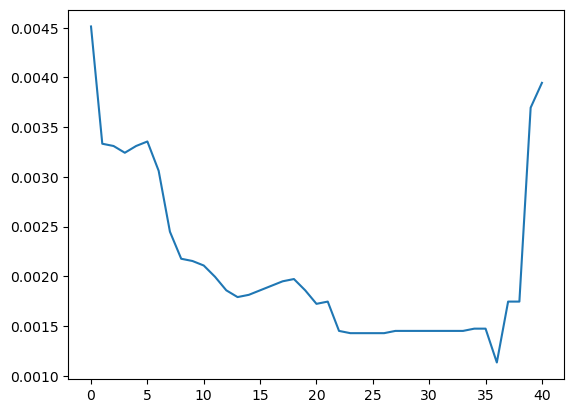

0.00017290249433106575

In [36]:
import matplotlib.pyplot as plt
def jitterr(x,sr):
    prd=[]
    for i in range(0,len(x)-2048,512):
        frame=x[i:i+2048]
        if np.max(np.abs(frame))<0.01:continue  
        r=np.correlate(frame,frame,'full')[2048:]
        lag_start=40
        lag_end=200
        peak=np.argmax(r[lag_start:lag_end])+lag_start
        prd.append(peak/sr)
    if len(prd)>1:
        plt.plot(prd)
        plt.show()
        return np.mean(np.abs(np.diff(prd)))
    else:
        return 1e-5
    
    

jitterr(y,sr)
jitterr(x,sr)

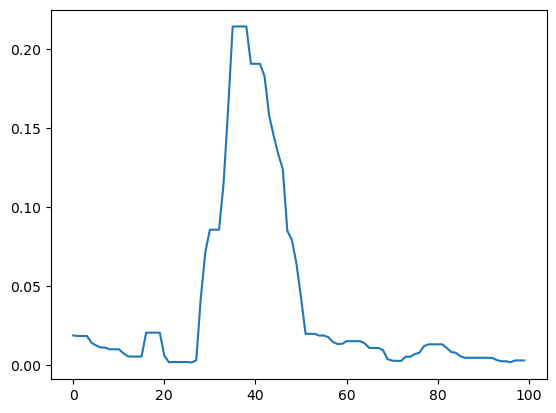

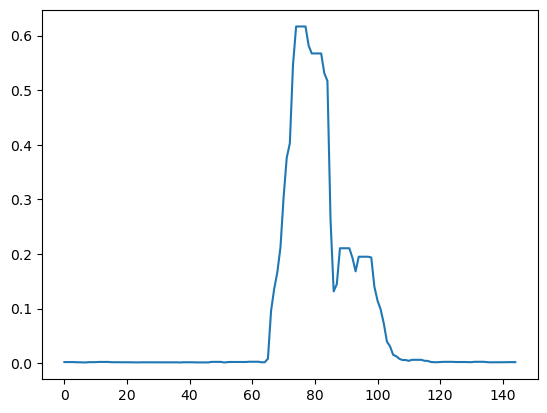

0.010114882

In [37]:
def shimmerr(x):
    amps=[]
    for i in range(0,len(x)-2048,512):
        f=x[i:i+2048]
        amps.append(np.max(np.abs(f)))
    amps=np.array(amps)
    if len(amps)>1:
        plt.plot(amps)
        plt.show()
        return np.mean(np.abs(np.diff(amps)))

shimmerr(y)
shimmerr(x)

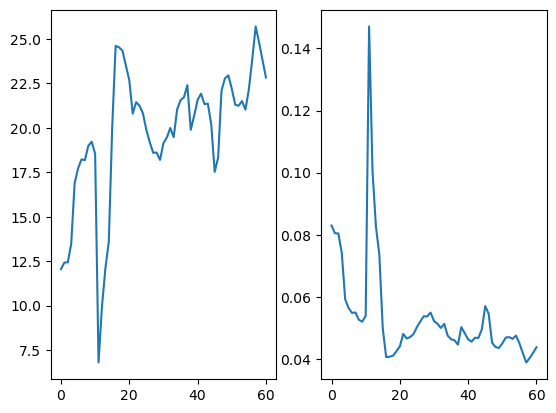

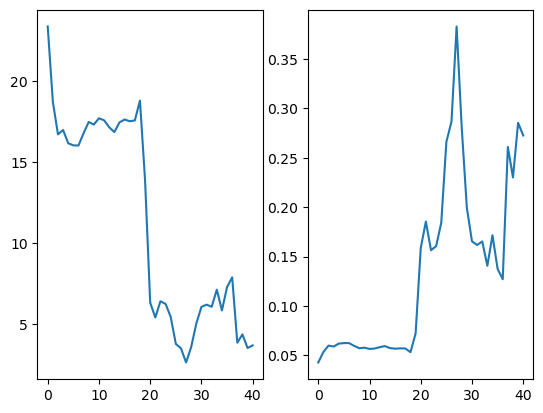

11.160850925161952

In [38]:
def hnr(x):
    hns=[]
    nhr=[]
    for i in range(0,len(x)-2048,512):
        f=x[i:i+2048]
        if np.max(np.abs(f))<0.01: continue  
        r=np.correlate(f,f,'full')[2048:]
        pk=np.argmax(r[1:200])+1
        num=r[pk]+1e-6
        den=r[0]-r[pk]+1e-6
        if den<=0 or num<=0: continue
        h=10*np.log10(num/den)
        hns.append(h)
        nhr.append(1/h)
    if len(hns):
        plt.subplot(1,2,1)
        plt.plot(hns)
        plt.subplot(1,2,2)
        plt.plot(nhr)
        plt.show()
        return np.mean(hns)
    else:
        return 1e-4

hnr(y)
hnr(x)

In [39]:
def nhr(hnr):
    return 1/(1+hnr) if hnr>0 else 1

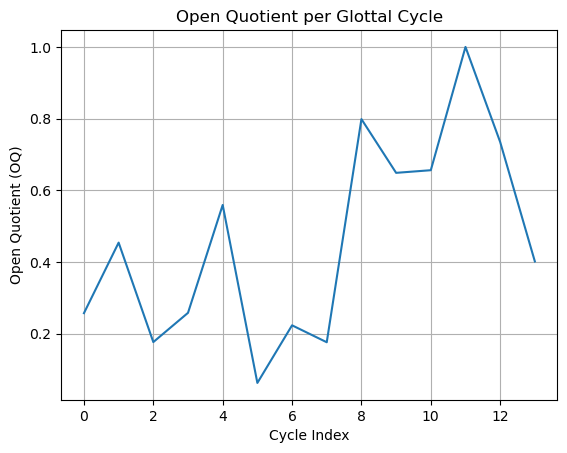

Estimated Open Quotient (OQ) for NewOneData/Female/ManyaA.wav: 0.4576


In [40]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, lfilter

def glottal(y, sr, order=16): 
    frame = y[0:2048]  
    frame = frame * np.hamming(len(frame))
    a = librosa.lpc(frame, order=order)  
    glottal_flow = lfilter(a, [1.0], frame)  
    return glottal_flow

def estimate_open_quotient(glottal, sr):
    peaks, _ = find_peaks(glottal, distance=sr // 400) 
    oqs = []

    for i in range(len(peaks) - 1):
        start = peaks[i]
        end = peaks[i + 1]
        cycle = glottal[start:end]

        if len(cycle) < 3:
            continue

        d = np.diff(cycle)
        closure_point = np.argmin(d)
        T_closed = closure_point
        T_open = len(cycle) - T_closed
        T_cycle = len(cycle)

        if T_cycle > 0:
            oq = T_open / T_cycle
            oqs.append(oq)

    if oqs:
        plt.plot(oqs)
        plt.title("Open Quotient per Glottal Cycle")
        plt.xlabel("Cycle Index")
        plt.ylabel("Open Quotient (OQ)")
        plt.grid(True)
        plt.show()
        return np.mean(oqs)
    else:
        return 1e-4  


file_path = "NewOneData/Female/ManyaA.wav"  
y, sr = librosa.load(file_path, sr=None)


g_signal = glottal(y, sr)
oq_value = estimate_open_quotient(g_signal, sr)

print(f"Estimated Open Quotient (OQ) for {file_path}: {oq_value:.4f}")


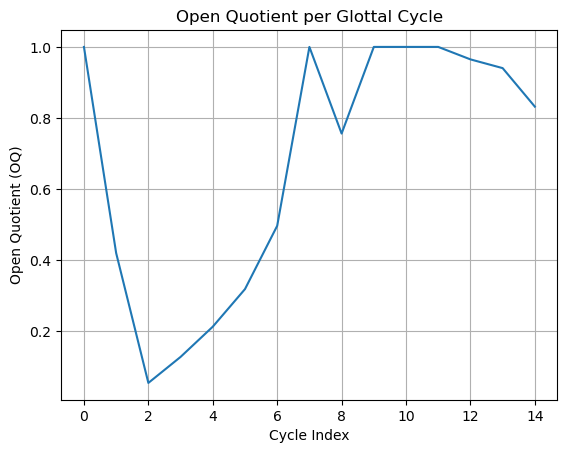

In [41]:
g_signal = glottal(x, sr)
oq = estimate_open_quotient(g_signal, sr)

In [42]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import scipy.signal 

def compute_gne(signal, sr):
    gne_vals = []
    frame_length = 2048
    hop_length = 512

    for i in range(0, len(signal) - frame_length, hop_length):
        frame = signal[i:i + frame_length]

    
        if np.max(np.abs(frame)) < 0.01:
            continue

        r = np.correlate(frame, frame, mode='full')
        r = r[frame_length:]


        pk = np.argmax(r[1:200]) + 1


        gne = r[pk] / (r[0] + 1e-6) 
        gne_vals.append(gne)

    return gne_vals



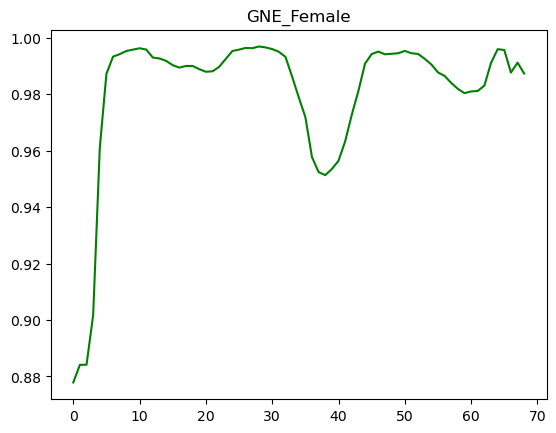

In [43]:
gne_val = compute_gne(y,sr)
plt.plot(gne_val, color='g')
plt.title('GNE_Female')
plt.show()

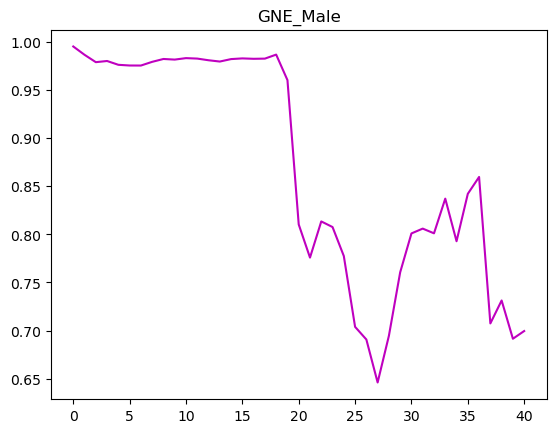

In [44]:
gne_val = compute_gne(x,sr)
plt.plot(gne_val, color='m')
plt.title('GNE_Male')
plt.show()

In [45]:
import librosa
import numpy as np

def compute_vfer(y,sr):
    frame_length = int(0.025 * sr)
    hop_length = int(0.01 * sr)

    f0, voiced_flag, _ = librosa.pyin(y, fmin=75, fmax=300, sr=sr, frame_length=frame_length, hop_length=hop_length)

    frames = range(0, len(y) - frame_length, hop_length)
    energy = [np.sum(y[i:i + frame_length] ** 2) for i in frames]

    min_len = min(len(energy), len(voiced_flag))
    voiced_flag = voiced_flag[:min_len]
    energy = energy[:min_len]

    vfer_framewise = []
    for i in range(min_len):
        voiced_energy = energy[i] if voiced_flag[i] else 0
        total_energy = energy[i]
        vfer = voiced_energy / (total_energy + 1e-6)
        vfer_framewise.append(vfer)
    if vfer_framewise:
        plt.plot(vfer_framewise)
        plt.show()
        return vfer_framewise
    else:
        return 1e-4

C:\Users\khush\AppData\Local\Temp\ipykernel_7620\2980012054.py:8: UserWarning: With fmin=75.000, sr=44100 and frame_length=1102, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=80.036 or frame_length=1177.
  f0, voiced_flag, _ = librosa.pyin(y, fmin=75, fmax=300, sr=sr, frame_length=frame_length, hop_length=hop_length)


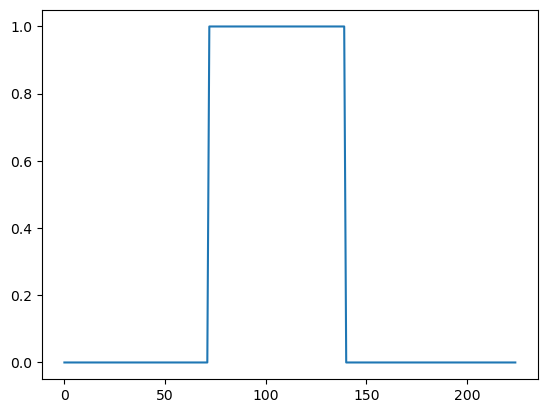

Final VFER value: 0.3022


In [46]:
vfer_val = compute_vfer(y,sr)
vfer_mean = np.mean(vfer_val)
print("Final VFER value:", round(vfer_mean, 4))

C:\Users\khush\AppData\Local\Temp\ipykernel_7620\2980012054.py:8: UserWarning: With fmin=75.000, sr=44100 and frame_length=1102, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=80.036 or frame_length=1177.
  f0, voiced_flag, _ = librosa.pyin(y, fmin=75, fmax=300, sr=sr, frame_length=frame_length, hop_length=hop_length)


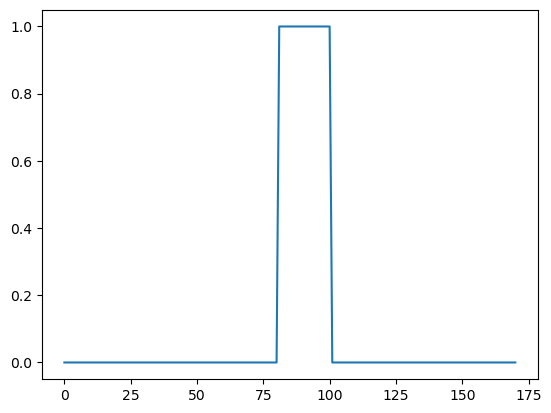

Final VFER value: 0.117


In [47]:
vfer_val = compute_vfer(x,sr)
vfer_mean = np.mean(vfer_val)
print("Final VFER value:", round(vfer_mean, 4))

In [48]:
import parselmouth
import numpy as np
import matplotlib.pyplot as plt

def vtl(audio_path, plot=False):
    try:
        snd = parselmouth.Sound(audio_path)
        formant = snd.to_formant_burg(time_step=0.01, max_number_of_formants=5, maximum_formant=5500)
        times = formant.ts()

        f1_values = []
        for t in times:
            f1 = formant.get_value_at_time(1, t)
            if f1 is not None and 250 < f1 < 1000: 
                f1_values.append(f1)

        if len(f1_values) == 0:
            return 1e-4

        avg_f1 = np.mean(f1_values)
        vtl_cm = 35000 / (4 * avg_f1)

        if plot:
            plt.plot(f1_values)
            plt.title(f"F1 Trajectory - {audio_path}")
            plt.ylabel("F1 (Hz)")
            plt.xlabel("Frame")
            plt.grid(True)
            plt.show()

        return round(vtl_cm, 2)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return 1e-4


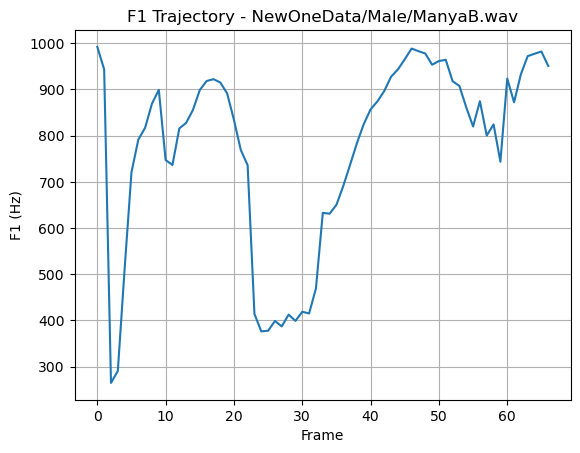

Estimated VTL: 11.35 cm


In [49]:
vtl_cm = vtl("NewOneData/Male/ManyaB.wav", plot=True)
print("Estimated VTL:", vtl_cm, "cm")

In [50]:
vtl("NewOneData/Male/ManyaB.wav")

11.35

In [52]:
vtl("NewOneData/Female/ManyaS.wav")

17.43

In [53]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import parselmouth
import pandas as pd
from scipy.signal import find_peaks, lfilter


female_dir = "NewOneData/Female"
male_dir = "NewOneData/Male"


def jitterr(x, sr):
    prd = []
    for i in range(0, len(x) - 2048, 512):
        frame = x[i:i + 2048]
        if np.max(np.abs(frame)) < 0.01:
            continue
        r = np.correlate(frame, frame, 'full')[2048:]
        lag_start = 40
        lag_end = 200
        peak = np.argmax(r[lag_start:lag_end]) + lag_start
        prd.append(peak / sr)
    return np.mean(np.abs(np.diff(prd))) if len(prd) > 1 else 1e-5

def shimmerr(x):
    amps = [np.max(np.abs(x[i:i+2048])) for i in range(0, len(x)-2048, 512)]
    amps = np.array(amps)
    return np.mean(np.abs(np.diff(amps))) if len(amps) > 1 else 1e-5

def hnr_func(x):
    hns = []
    for i in range(0, len(x) - 2048, 512):
        f = x[i:i + 2048]
        if np.max(np.abs(f)) < 0.01:
            continue
        r = np.correlate(f, f, 'full')[2048:]
        pk = np.argmax(r[1:200]) + 1
        num = r[pk] + 1e-6
        den = r[0] - r[pk] + 1e-6
        if den <= 0 or num <= 0:
            continue
        h = 10 * np.log10(num / den)
        hns.append(h)
    return np.mean(hns) if len(hns) else 1e-4

def nhr_from_hnr(hnr_val):
    return 1 / (1 + hnr_val) if hnr_val > 0 else 1

def glottal(y, sr, order=16): 
    frame = y[0:2048] * np.hamming(2048)
    a = librosa.lpc(frame, order=order)  
    return lfilter(a, [1.0], frame)  

def estimate_open_quotient(glottal, sr):
    peaks, _ = find_peaks(glottal, distance=sr // 400)
    oqs = []
    for i in range(len(peaks) - 1):
        start, end = peaks[i], peaks[i + 1]
        cycle = glottal[start:end]
        if len(cycle) < 3:
            continue
        d = np.diff(cycle)
        closure_point = np.argmin(d)
        T_closed = closure_point
        T_open = len(cycle) - T_closed
        T_cycle = len(cycle)
        if T_cycle > 0:
            oq = T_open / T_cycle
            oqs.append(oq)
    return np.mean(oqs) if oqs else 1e-4

def compute_gne(signal, sr):
    gne_vals = []
    for i in range(0, len(signal) - 2048, 512):
        frame = signal[i:i + 2048]
        if np.max(np.abs(frame)) < 0.01:
            continue
        r = np.correlate(frame, frame, mode='full')[2048:]
        pk = np.argmax(r[1:200]) + 1
        gne = r[pk] / (r[0] + 1e-6)
        gne_vals.append(gne)
    return np.mean(gne_vals) if gne_vals else 1e-4

def compute_vfer(y, sr):
    frame_length = int(0.025 * sr)
    hop_length = int(0.01 * sr)
    f0, voiced_flag, _ = librosa.pyin(y, fmin=75, fmax=300, sr=sr,
                                      frame_length=frame_length, hop_length=hop_length)
    frames = range(0, len(y) - frame_length, hop_length)
    energy = [np.sum(y[i:i + frame_length] ** 2) for i in frames]
    min_len = min(len(energy), len(voiced_flag))
    voiced_flag = voiced_flag[:min_len]
    energy = energy[:min_len]
    vfer_framewise = [(energy[i] if voiced_flag[i] else 0) / (energy[i] + 1e-6)
                      for i in range(min_len)]
    return np.mean(vfer_framewise) if vfer_framewise else 1e-4

def vtl(audio_path):
    try:
        snd = parselmouth.Sound(audio_path)
        formant = snd.to_formant_burg(time_step=0.01, max_number_of_formants=5, maximum_formant=5500)
        times = formant.ts()
        f1_values = [formant.get_value_at_time(1, t) for t in times if formant.get_value_at_time(1, t) and 250 < formant.get_value_at_time(1, t) < 1000]
        avg_f1 = np.mean(f1_values) if f1_values else 1e-4
        return round(35000 / (4 * avg_f1), 2) if avg_f1 > 0 else 1e-4
    except:
        return 1e-4


all_data = []

def process_directory(directory, label):
    for file in os.listdir(directory):
        if file.endswith(".wav"):
            path = os.path.join(directory, file)
            try:
                y, sr = librosa.load(path, sr=None)
                g_signal = glottal(y, sr)

                features = {
                    "Filename": file,
                    "Label": label,
                    "Jitter": jitterr(y, sr),
                    "Shimmer": shimmerr(y),
                    "HNR": hnr_func(y),
                    "NHR": nhr_from_hnr(hnr_func(y)),
                    "OpenQuotient": estimate_open_quotient(g_signal, sr),
                    "GNE": compute_gne(y, sr),
                    "VFER": compute_vfer(y, sr),
                    "VTL": vtl(path)
                }
                all_data.append(features)
            except Exception as e:
                print(f"Error processing {file}: {e}")


process_directory(female_dir, "Female")
process_directory(male_dir, "Male")


df = pd.DataFrame(all_data)
df.to_csv("acoustic_features_female_male.csv", index=False)

print("Features saved to 'acoustic_features_female_male.csv'")


C:\Users\khush\AppData\Local\Temp\ipykernel_7620\2900919833.py:89: UserWarning: With fmin=75.000, sr=44100 and frame_length=1102, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=80.036 or frame_length=1177.
  f0, voiced_flag, _ = librosa.pyin(y, fmin=75, fmax=300, sr=sr,


Features saved to 'acoustic_features_female_male.csv'


In [55]:
import pandas as pd

df = pd.read_csv("acoustic_features_female_male.csv")

display(df)  


,Filename,Label,Jitter,Shimmer,HNR,NHR,OpenQuotient,GNE,VFER,VTL
0,Aashi1.wav,Female,0.000172,0.007928,14.805384,0.063270,0.637607,0.934057,0.815745,14.91
1,AashiA.wav,Female,0.000240,0.013117,15.045168,0.062324,0.483346,0.888246,0.276422,13.22
2,AashiK.wav,Female,0.000882,0.009908,13.918212,0.067032,0.576344,0.918679,0.199999,15.28
3,AashiM.wav,Female,0.000429,0.016985,12.620000,0.073421,0.667240,0.859851,0.229166,11.99
4,AashiS.wav,Female,0.000396,0.005543,15.752727,0.059692,0.651172,0.916540,0.216418,12.92
...,...,...,...,...,...,...,...,...,...,...
95,Yash2.wav,Male,0.000231,0.008767,14.236971,0.065630,0.712809,0.883585,0.409620,14.41
96,YashB.wav,Male,0.000269,0.004217,8.746541,0.102601,0.589575,0.867543,0.206833,13.65
97,YashR.wav,Male,0.000590,0.008695,11.308073,0.081247,0.609357,0.836208,0.186916,13.22
98,YashSS.wav,Male,0.000888,0.012125,8.993648,0.100064,0.606236,0.745471,0.000000,14.75


In [56]:
df.to_excel("acoustic_features_female_male.xlsx", index=False)

print("Saved as Excel: acoustic_features_female_male.xlsx")


Saved as Excel: acoustic_features_female_male.xlsx


Best SVM Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.67      0.76        12
           1       0.64      0.88      0.74         8

    accuracy                           0.75        20
   macro avg       0.76      0.77      0.75        20
weighted avg       0.79      0.75      0.75        20

Accuracy: 75.0 %


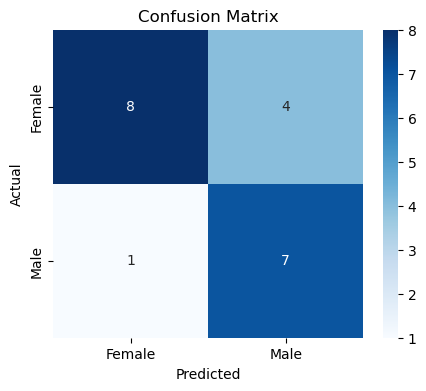

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("acoustic_features_female_male.csv")

label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])  # Male = 0, Female = 1

X = df.drop(columns=["Filename", "Label"]) 
y = df["Label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto']
}

svm = SVC()
grid = GridSearchCV(svm, param_grid, cv=5)
grid.fit(X_train, y_train)


y_pred = grid.predict(X_test)

print("Best SVM Parameters:", grid.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Accuracy: 65.0 %

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1       0.55      0.75      0.63         8

    accuracy                           0.65        20
   macro avg       0.66      0.67      0.65        20
weighted avg       0.68      0.65      0.65        20



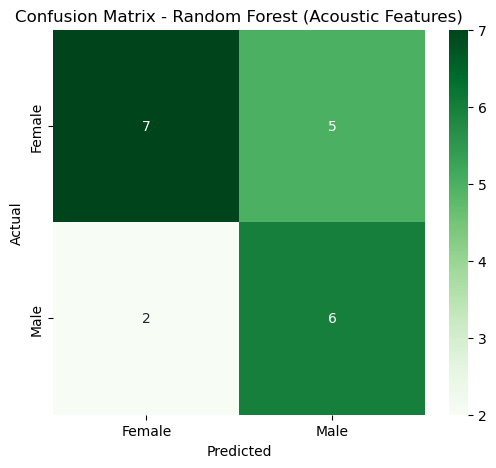

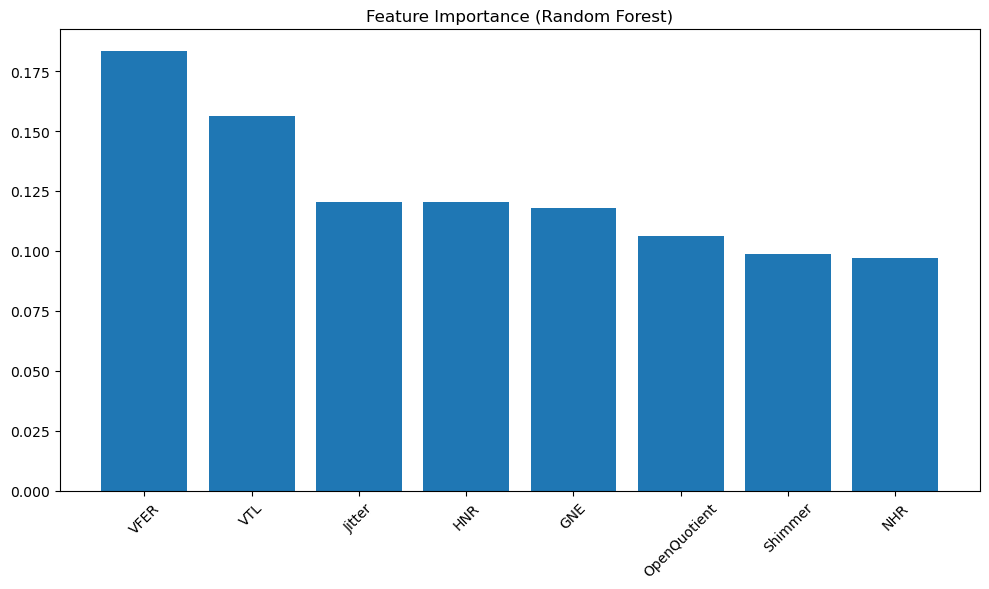

In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv("acoustic_features_female_male.csv")


le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])  # Female = 1, Male = 0


X = df.drop(columns=['Filename', 'Label'])
y = df['Label']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Acoustic Features)")
plt.show()


importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()
